# Exploring Neural Architecture Search

Group Member details

## Introduction & Motivation

Designing high-performing neural network architectures often involves manual trial-and-error or exhaustive search over hyperparameters. This process is time-consuming and may not generalize well across tasks.

Neural Architecture Search (NAS) aims to automate this design process and discover optimal architectures for a given task. Compared to traditional CNN/RNN tuning, NAS significantly reduces human effort and can potentially discover novel architectures that are on par or even outperform hand-crafted models.

### What is Neural Architecture Search (NAS)

As stated above, NAS is an emerging subfield of Deep Learning that automates hyperparameter tuning for discovering optimal architectures. NAS typically focuses on hyperparameters that influence architecture design as compared to ones like learning rate or batch size which influence model training. This is done to speed up the model development process and align more with the intent of discovering architectures that are smaller, faster, more accurate, or more efficient. NAS consists of three major components:
- **Search Space:** This defines the search space of possible architectures that NAS can explore
- **Search Strategy:** The techniques used by NAS to explore and traverse the search space. These involve reinforcement learning, evolutionary algorithms, Bayesian optimization, etc.
- **Evaluation Strategy:** The strategy used to evaluate candidate architectures

#### NAS with RL

Refer to paper

Why we chose this paper


### Related Work

Briefly mention other NAS approaches (e.g., DARTS, ENAS) to situate your work.


### Components of NAS with RL

1-2 lines each

#### Controller

#### Child Model

#### Reinforcement Learning loop

Using the paper as a reference we try to implement the algorithm presented and conduct experiments to further our understanding of the interaction of the controller and child models in an RL env

### Experiments

bullet point list/simple table explain each in 1 line

## Implementation

Imports and setup

In [2]:
import torch
import torch.nn as nn
import time
from torch.utils.data import DataLoader
import os

import analysis
import utils
import logging
from CNN_NAS.ChildCNNModel import ChildCNNModel
from CNN_NAS.CNNController import CNNController
import reward_functions
import predefined_models
import analysis

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

device = utils.get_device_available()
print(torch.__version__)
print(device)

%load_ext autoreload
%autoreload 2

2.1.2.post4
mps


### Controller

For our implementation we model a neural network architecture as a sequence of layers. We use an LSTM-based RNN architecture for our controller that sequentially generates CNN layer configurations. It uses a meta layer to embed dataset-specific information into the initial hidden and cell states of the LSTM. At each step, the LSTM outputs logits for filter size, kernel size, and padding, which are sampled to define a layer. Positional encodings are added to the input embeddings to make the controller aware of layer depth. The process repeats for a fixed number of layers to produce a complete architecture.

`<Insert Image Here>`




#### Vocabulary

To keep the search space limited and feasible to run on our laptop GPUs we decided to restrict our layer design to a very few set of parameters. Our controller is designed to generate a CNN layer which is encoded as a tuple with the following structure:

```
(<num_of_output_channels/activation_maps>, <kernel_size>, <padding>)
```

The vocabulary is defined as follows

```python
FILTER_CHOICES = [16, 32, 64, 128, 256]
KERNEL_CHOICES = [1, 3, 5]
PADDING_CHOICES = [0, 1, 2]
```

Therefore, there are a total of `5 * 3 * 3 = 36` unique layers that can be generated. If a controller is sampling a model with 2 CNN layers the search space consists of `36**2 = 1296` unique models. Similarly, for a 3-layer model, the search space comprises `36**3 = 46,656` unique models.




#### Controller Architecture

The meta layer is a small MLP used to project dataset metadata (input size and number of classes) into the initial hidden and memory state for the LSTM. By modelling it this way we try to let the controller use this extra information to try to augment its search. Specifying this layer is optional. Since we don't use a bias in this layer, not specifying this information will always initialize `h_init` and `c_init` to 0.

```python
self.meta_layer = nn.Sequential(
    nn.Linear(2, 64, bias=False),
    nn.ReLU(),
    nn.Linear(64, 2 * hidden_dim, bias=False)
)


self.meta = torch.tensor([[0.0, 0.0]]) if meta is None else (
    meta if isinstance(meta, torch.Tensor) else torch.tensor([meta], dtype=torch.float)
)
```

The core controller is then composed of an LSTM cell that generates the logits for number of channels (filter_size), kernel size, and padding.

```python
self.rnn = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True)

self.fc_filter = nn.Linear(hidden_dim, len(FILTER_CHOICES))
self.fc_kernel = nn.Linear(hidden_dim, len(KERNEL_CHOICES))
self.fc_padding = nn.Linear(hidden_dim, len(PADDING_CHOICES))
```




#### Forward Pass

At each step, the LSTM outputs logits for filter channels, kernel size, and padding, which are sampled to define a layer. Positional encodings, inspired by transformers, are added to the input embeddings to make the controller aware of layer depth.

The forward pass takes in:

- A token (representing previous layer config)
- A position index
- Optional hidden state (else generated from metadata)

```python
def forward(self, input_token, pos_idx, hidden=None):
    if hidden is None:
        meta_encoding = self.meta_layer(self.meta.to(input_token.device))
        h_init = meta_encoding[:, :self.hidden_dim]
        c_init = meta_encoding[:, self.hidden_dim:]
        hidden = (
            h_init.view(self.num_layers, 1, self.hidden_dim),
            c_init.view(self.num_layers, 1, self.hidden_dim)
        )

    x = self.embedding(input_token)

    # Positional Encoding
    pe = self.sinusoidal_encoding(pos_idx, x.size(-1)).to(x.device)
    x = x + pe

```

#### Sequence Generation


The controller includes a method `generate_sequence` that takes as input `max_layers` the number of CNN layers to generate.

```python
def generate_sequence(self, max_layers=1):
    self.eval()
    sequence = []
    log_probs = []
```

For each layer:

1. Call `self.forward(...)` to get logits.
2. Create categorical distributions.
3. Sample from each.
4. Track the log-probability (needed for REINFORCE).

```python
f_dist = torch.distributions.Categorical(logits=f_logits[:, -1, :])
f_token = f_dist.sample()
log_prob = f_dist.log_prob(f_token) + ...
```

5. Use the sampled token to encode the next input.

```python
combo_token = f_token * (K * P) + k_token * P + p_token
input_token = combo_token.view(1, 1)
```

This method repeats the above process for `max_layers` steps and returns the sampled architecture and its cumulative log-probabilities.


In [ ]:
# Define search space
FILTER_CHOICES = [16, 32, 64, 128, 256]
KERNEL_CHOICES = [1, 3, 5]
PADDING_CHOICES = [0, 1, 2]

FILTER_VOCAB = {str(val): idx for idx, val in enumerate(FILTER_CHOICES)}
KERNEL_VOCAB = {str(val): idx for idx, val in enumerate(KERNEL_CHOICES)}
PADDING_VOCAB = {str(val): idx for idx, val in enumerate(PADDING_CHOICES)}

IDX_TO_FILTER = {idx: val for val, idx in FILTER_VOCAB.items()}
IDX_TO_KERNEL = {idx: val for val, idx in KERNEL_VOCAB.items()}
IDX_TO_PADDING = {idx: val for val, idx in PADDING_VOCAB.items()}


class CNNController(nn.Module):
    def __init__(self, embedding_dim=8, hidden_dim=32, num_layers=1, name="CNN", meta=None, max_layers=10, type="CNN"):
        super(CNNController, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=len(FILTER_CHOICES) * len(KERNEL_CHOICES) * len(PADDING_CHOICES),
            embedding_dim=embedding_dim
        )

        self.rnn = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True)

        self.fc_filter = nn.Linear(hidden_dim, len(FILTER_CHOICES))
        self.fc_kernel = nn.Linear(hidden_dim, len(KERNEL_CHOICES))
        self.fc_padding = nn.Linear(hidden_dim, len(PADDING_CHOICES))

        self.meta_layer = nn.Sequential(
            nn.Linear(2, 64, bias=False),
            nn.ReLU(),
            nn.Linear(64, 2 * hidden_dim, bias=False)
        )

        self.hidden_dim = hidden_dim
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers
        self.name = name
        self.max_layers = max_layers
        self.type = type

        self.meta = torch.tensor([[0.0, 0.0]]) if meta is None else (
            meta if isinstance(meta, torch.Tensor) else torch.tensor([meta], dtype=torch.float)
        )

    def sinusoidal_encoding(self, pos, d_model):
        """
        Generate fixed sinusoidal positional encoding for a given position.
        Returns: [1, 1, d_model] tensor
        """
        pe = torch.zeros(d_model)
        position = torch.tensor(pos, dtype=torch.float32)

        for i in range(0, d_model, 2):
            div_term = torch.tensor(10000.0 ** (i / d_model), dtype=torch.float32)
            pe[i] = torch.sin(position / div_term)
            if i + 1 < d_model:
                pe[i + 1] = torch.cos(position / div_term)

        return pe.view(1, 1, -1)  # [1, 1, d_model]

    def forward(self, input_token, pos_idx, hidden=None):
        # input_token: [1, 1], pos_idx: int or tensor

        if hidden is None:
            meta_encoding = self.meta_layer(self.meta.to(input_token.device))
            h_init = meta_encoding[:, :self.hidden_dim]
            c_init = meta_encoding[:, self.hidden_dim:]
            hidden = (
                h_init.view(self.num_layers, 1, self.hidden_dim),
                c_init.view(self.num_layers, 1, self.hidden_dim)
            )

        x = self.embedding(input_token)  # [1, 1, emb_dim]
        pe = self.sinusoidal_encoding(pos_idx, x.size(-1)).to(x.device)  # [1, 1, emb_dim]
        x = x + pe

        output, hidden = self.rnn(x, hidden)

        filter_logits = self.fc_filter(output)
        kernel_logits = self.fc_kernel(output)
        padding_logits = self.fc_padding(output)

        return filter_logits, kernel_logits, padding_logits, hidden

    def generate_sequence(self, max_layers=1):
        self.eval()
        sequence = []
        log_probs = []

        K = len(KERNEL_CHOICES)
        P = len(PADDING_CHOICES)

        input_token = torch.zeros(1, 1, dtype=torch.long)
        hidden = None

        for layer_idx in range(max_layers):
            f_logits, k_logits, p_logits, hidden = self.forward(input_token, layer_idx, hidden)

            f_dist = torch.distributions.Categorical(logits=f_logits[:, -1, :])
            k_dist = torch.distributions.Categorical(logits=k_logits[:, -1, :])
            p_dist = torch.distributions.Categorical(logits=p_logits[:, -1, :])

            f_token = f_dist.sample()
            k_token = k_dist.sample()
            p_token = p_dist.sample()

            log_prob = f_dist.log_prob(f_token) + k_dist.log_prob(k_token) + p_dist.log_prob(p_token)

            layer = (
                IDX_TO_FILTER[f_token.item()],
                IDX_TO_KERNEL[k_token.item()],
                IDX_TO_PADDING[p_token.item()]
            )
            sequence.append(layer)
            log_probs.append(log_prob)

            # Prepare next input token
            combo_token = f_token * (K * P) + k_token * P + p_token
            input_token = combo_token.view(1, 1)

        return sequence, torch.stack(log_probs)

### Child Network Class

In depth explanation of our child implementation
- What is a child network
- Predefined models and injecting layers in the model
- build_cnn_model_from_encoding function
- Train and test
<Provide code snippets wherever possible to illustrate the point being made>

### RL loop

In depth explanation of our RL implementation
- REINFORCE algorithm
- Explanation of parameters
- Reward functions
<Provide code snippets wherever possible to illustrate the point being made>

In [ ]:
def split_dataset(data, labels, split_ratio=0.8):
    dataset = torch.utils.data.TensorDataset(data, labels)
    train_size = int(split_ratio * len(dataset))
    test_size = len(dataset) - train_size

    train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_data, train_labels = zip(*train_set)
    train_data = torch.stack(train_data)
    train_labels = torch.stack(train_labels)

    test_data, test_labels = zip(*test_set)
    test_data = torch.stack(test_data)
    test_labels = torch.stack(test_labels)

    return (train_data, train_labels), (test_data, test_labels)


def train_controller(
        controller,
        train,
        base_model,
        test=None,
        model_iters=5,
        train_epochs=10,
        max_child_layers=5,
        positions=None,
        optimizer=None,
        baseline=0,
        reward_function=None,
        dataset_name=None,
):

    if positions is None:
        positions=[1]
        max_child_layers=1
    if not test:
        train, test = split_dataset(*train)

    if reward_function is None:
        reward_function = reward_functions.test_accuracy_reward

    if not optimizer:
        optimizer = torch.optim.Adam(controller.parameters(), lr=0.001)


    max_accuracy = 0
    gamma = 0.9

    train_x, train_y = train
    test_x, test_y = test

    if len(train_x.size())==3:
        train_x = train_x.unsqueeze(1)

    if len(test_x.size())==3:
        test_x = test_x.unsqueeze(1)

    num_channels = train_x.size(1)
    height = train_x.size(2)
    width = train_x.size(3)
    output_dim = torch.max(train_y).item() + 1


    logger.info(f"Training set shape: {train_x.size()}")

    print("Controller will be saved to: ", os.path.join("Models", "Controller", controller.type, f"{controller.name}.pt"))
    print("Best child model will be saved to: ", os.path.join("Models", "Child", controller.type, f"{controller.name}.pt"))
    print("Training results will be saved to: ", os.path.join("Results", "Controller", controller.type, f"{controller.name}.csv"))
    print()

    for i in range(model_iters):
        logger.info(f"------ ITERATION {i} ------")

        layer_encoding, log_probs = controller.generate_sequence(max_layers=max_child_layers)

        logger.info(f"Layers generated: {str(layer_encoding)}")
        model_encoding  = utils.replace_multiple_conv_layers(base_model=base_model, generated_layers=layer_encoding, positions=positions, input_channels=num_channels)

        print(f"[ITER {i}] Model encoding = {model_encoding}")

        child_model = ChildCNNModel(model_encoding, num_channels,height,width, output_dim).to(device)

        # print(child_model)
        logger.info(str(child_model))

        # Train child model
        child_model_loss, train_time = child_model.train_model(
            train_x,
            train_y,
            nn.CrossEntropyLoss(),
            torch.optim.Adam(child_model.parameters(), lr=0.001),
            device,
            epochs=train_epochs,
            dataset_name=dataset_name
        )
        logger.info(f"CHILD MODEL LOSS: {child_model_loss} with train time {train_time}")

        accuracy, val_loss, reward = reward_function(child_model, test, device=device, dataset_name=dataset_name)

        logger.info(f"CHILD MODEL ACCURACY: {accuracy}")

        if accuracy > max_accuracy:
            max_accuracy = accuracy
            utils.save_child_model(child_model, accuracy, controller.name)

        advantage = torch.tensor([reward - baseline], dtype=torch.float32, device=log_probs[0].device)
        policy_gradient = -torch.sum(log_probs) * advantage.detach()

        print(f"train_loss: {child_model_loss}\tvalidation_loss: {val_loss}\ttest_acc: {accuracy}\ttrain_time: {train_time}\tpolicy_gradient: {policy_gradient}")


        baseline = (1 - gamma) * reward + gamma * baseline

        optimizer.zero_grad()
        policy_gradient.backward()
        optimizer.step()

        utils.save_progress(
            controller,
            optimizer,
            baseline,
            row_data=map(str,[child_model_loss, val_loss, accuracy, train_time, policy_gradient.item(), max_accuracy, baseline]),
            controller_type="CNN",
            headers=("train_loss", "val_loss", "test_acc", "train_time", "policy_gradient", "max_accuracy", "baseline")
        )

        logger.info(f"Policy gradient: {policy_gradient.item()}")

        utils.cleanup_child_model(child_model)
        logger.info("")

        print()

    return controller, optimizer

## Experiments

In [ ]:
def load_dataset(dataset="cifar"):
    if dataset=="cifar":
        data_path = utils.check_cifar_dataset_exists()

    elif dataset=="cifar100":
        data_path = utils.check_cifar100_dataset_exists()

    elif dataset=="mnist":
        data_path = utils.check_mnist_dataset_exists()

    else:
        raise ValueError("Dataset not supported")

    train_data, train_labels = (
        torch.load(data_path + f'{dataset}/train_data.pt', weights_only=True),
        torch.load(data_path + f'{dataset}/train_label.pt', weights_only=True)
    )

    test_data, test_labels = (
        torch.load(data_path + f'{dataset}/test_data.pt', weights_only=True),
        torch.load(data_path + f'{dataset}/test_label.pt', weights_only=True)
    )

    num_channels = 1

    if len(train_data.size())==4:
        num_channels=train_data.size(1)

    img_size = train_data.size(-1)

    train_label = torch.load(data_path + f'{dataset}/train_label.pt',weights_only=True)

    num_classes = train_label.unique().size(0)

    print(f"Image size: {img_size}")
    print(f"Number of channels: {num_channels}")
    print(f"Number of classes:  {num_classes}")

    return (train_data, train_labels), (test_data, test_labels), num_channels, img_size, num_classes


def run_experiment(
        experiment_name,
        dataset_name,
        base_model="benchmark",
        model_iters=5,
        train_epochs=10,
        max_child_layers=2,
        reward_function=reward_functions.test_accuracy_reward,
        reset_experiment=False,
        positions=None,
        use_metadata=True,
):

    if reset_experiment:
        utils.reset_experiment(experiment_name)

    if positions is None:
        positions=[1,2]

    # Create the log file directory if missing
    log_dir = os.path.join("LogFiles", "TrainingLogs")
    os.makedirs(log_dir, exist_ok=True)

    # Add the log file handler for this experiment
    log_file_handler = logging.FileHandler(os.path.join(log_dir, f"{experiment_name}.log"), mode="w")
    log_file_handler.setLevel(logging.INFO)

    logger.addHandler(log_file_handler)

    # Load the dataset
    train_data, test_data, num_channels, img_size, num_classes = load_dataset(dataset_name)

    # Load the base model
    if base_model == "lenet":
        base_model = predefined_models.get_lenet(num_channels, num_classes)
    elif base_model == "vgg":
        base_model = predefined_models.get_vgg11(num_channels, num_classes)
    elif base_model == "alexnet":
        base_model = predefined_models.get_alexnet(num_channels, num_classes)
    else:
        base_model = predefined_models.get_benchmarkModel(num_channels, num_classes)


    # Load controller if it exists
    try:
        meta_controller, optimizer, baseline = utils.load_controller(experiment_name)
    except FileNotFoundError:
        meta = torch.tensor([[img_size, num_classes]], dtype=torch.float) if use_metadata else None
        meta_controller = CNNController(name=experiment_name, meta=meta)
        baseline = 0
        optimizer = None


    logger.info("###############################################")
    logger.info("STARTING TRAINING")
    logger.info("###############################################")

    trained_controller, optimizer = train_controller(
        meta_controller,
        train_data,
        base_model,
        test=test_data,
        model_iters=model_iters,
        train_epochs=train_epochs,
        max_child_layers=max_child_layers,
        positions=positions,
        baseline=baseline,
        optimizer=optimizer,
        reward_function=reward_function
    )

    logger.removeHandler(log_file_handler)
    log_file_handler.close()


### Datasets Used

#### CIFAR-10

Exploration here

#### CIFAR-100

Exploration here

### Data Preprocessing

Explain fast transform

### Methodology

Analysis Points

- Training results (visualize) (can be combined with overlay)
- Reference lines for benchmarks
- Every 50 iterations (considering 300 model iters) (for all metrics) [tabulated]
    - Mean
    - Std dev
- Overlay graphs for comparison studies
- Token distribution per layer (overall)
    - Distribtion of individual vocab tokens (separate graphs for num_channels, filter_size, and padding)
- Plot Num parameters per iteration



EXTRACT FN COLS
- iteration
- layer_1_channels
- layer_1_filter
- layer_1_padding
- layer_2_channels
- layer_2_filter
- layer_2_padding
- layer_3_channel
- layer_3_filter
- layer_3_padding
- param_count
-

#### Benchmark models

#### Experiment 1

**2 layer/3 layer**

Description <br>
Method <br>
Results <br>
Analysis <br>

#### Experiment 2 - Can we modify the reward function to optimize for both accuracy and model efficiency?

In this experiment, we modify the reward function in the RL loop to balance test accuracy with model complexity. The goal is to guide the controller toward architectures that are both accurate and efficient (uses fewer parameters).

Description <br>
Method <br>
Results <br>
Analysis <br>

##### Approach

The reward function is changed to the following:

```
w1 = 1
w2 = 0.05
reward = w1 * accuracy - w2 * log(num_parameters)
```

Since the parameter count will be very high (~in the range of millions), we use log operation to scale down the values. The complexity is then applied as a penalty to the reward with a weight factor `w2`.

In [26]:
experiment_name = "EXP_6_CIFAR10"

In [ ]:
run_experiment(
    experiment_name,
    dataset_name="cifar",
    model_iters=300,
    train_epochs=50,
    positions=[1,2],
    reward_function=reward_functions.test_accuracy_with_model_complexity_reward,
    max_child_layers=2,
    reset_experiment=True,
    use_metadata=False,
)

✅ Fixed padding captured and exported 500 models to LogFiles/Output/EXP_6_CIFAR10_log.csv


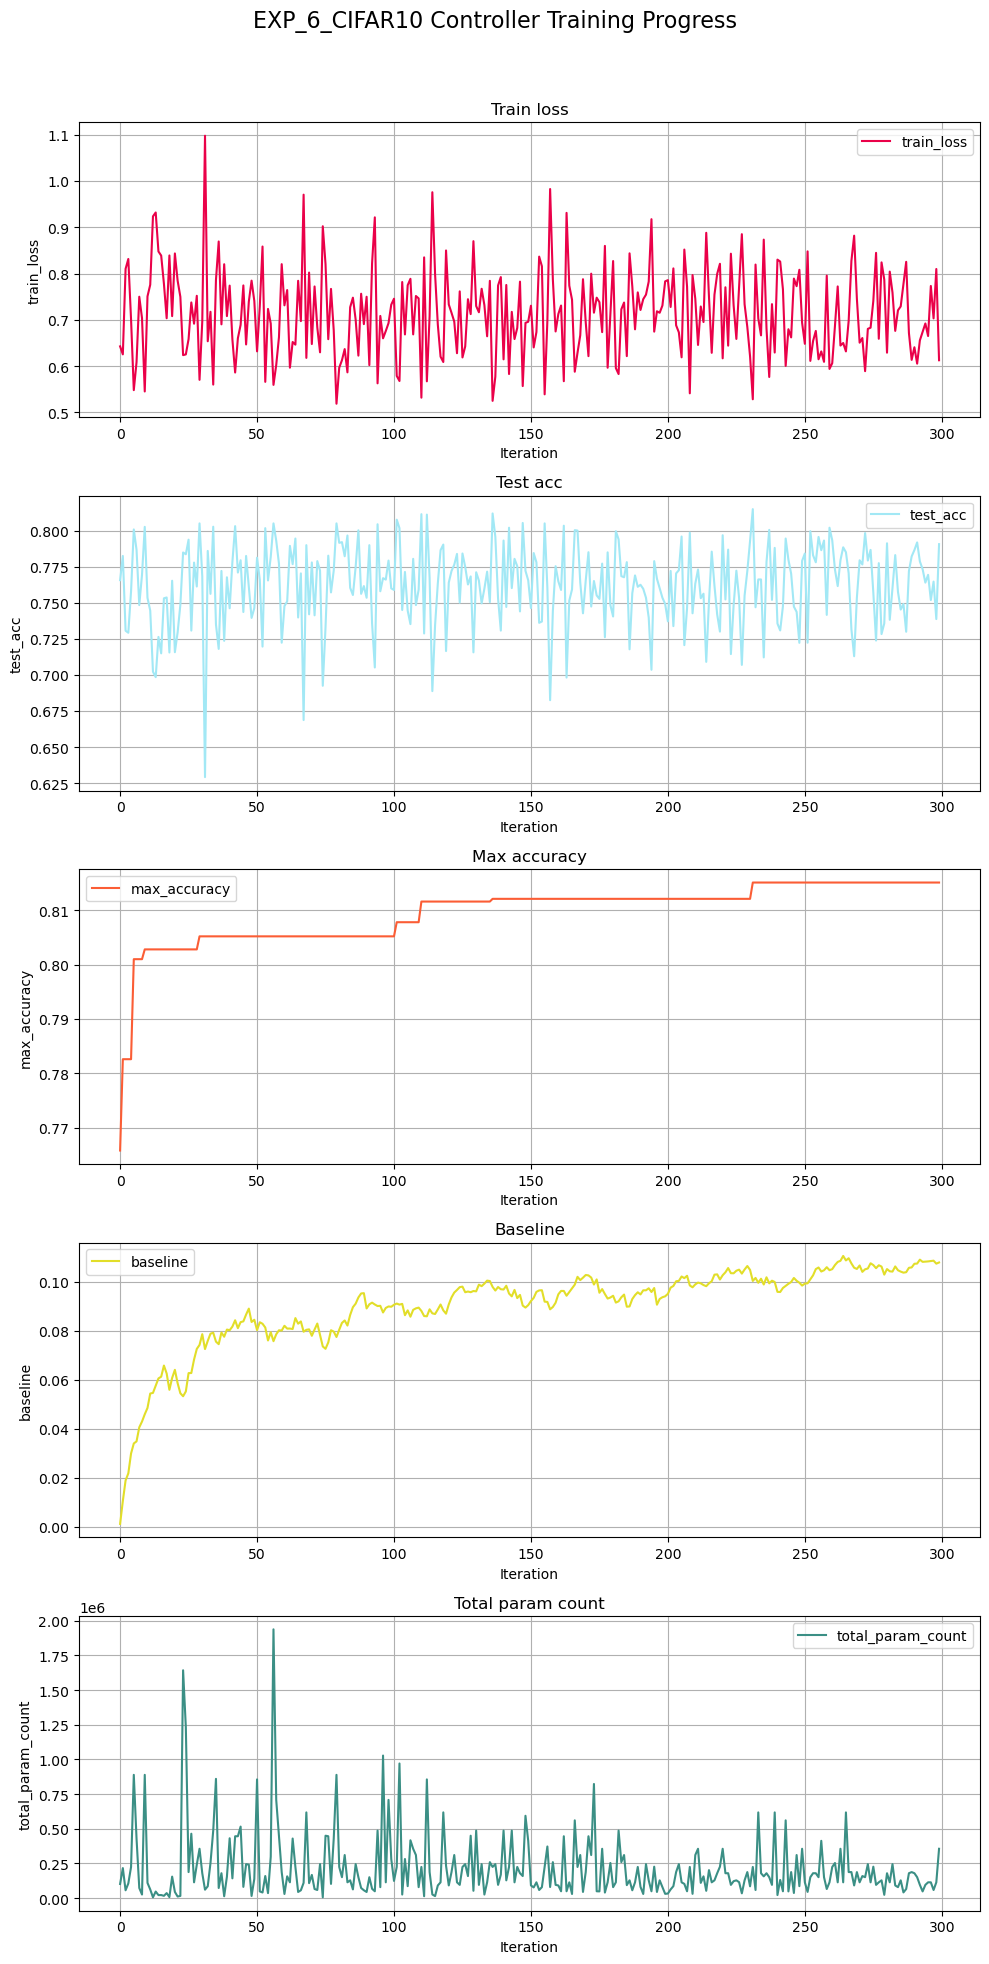

In [29]:
df_exp3 = analysis.get_full_training_log_data(experiment_name)
analysis.plot_metrics(df_exp3, experiment_name, metrics=["train_loss", "test_acc", "max_accuracy", "baseline", "total_param_count"], limit=300)

##### Analysis

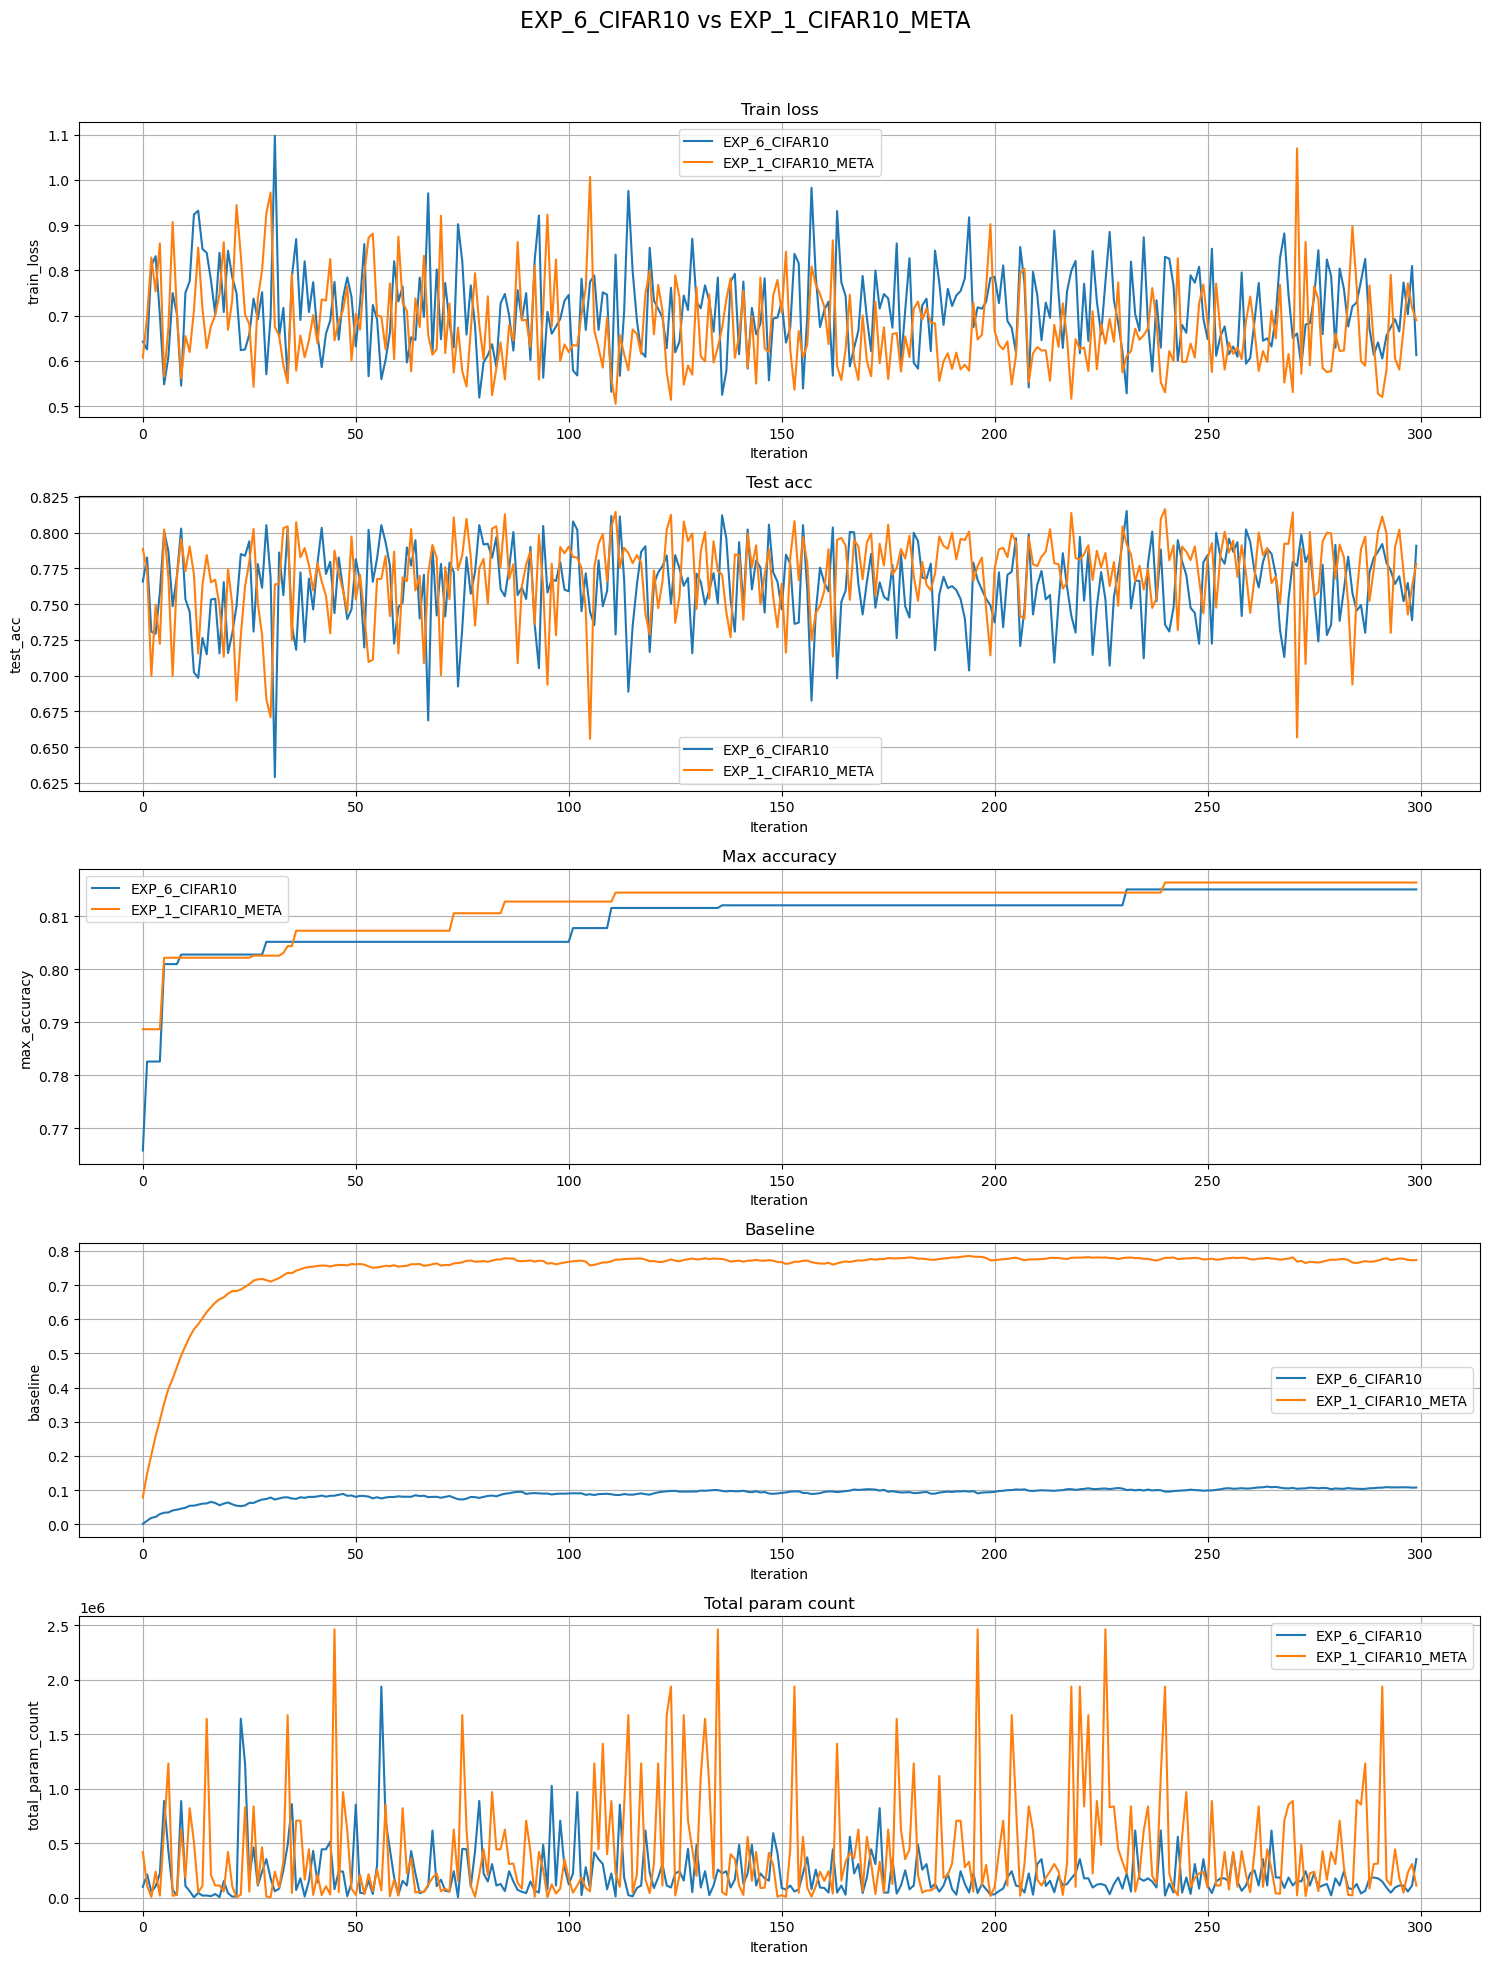

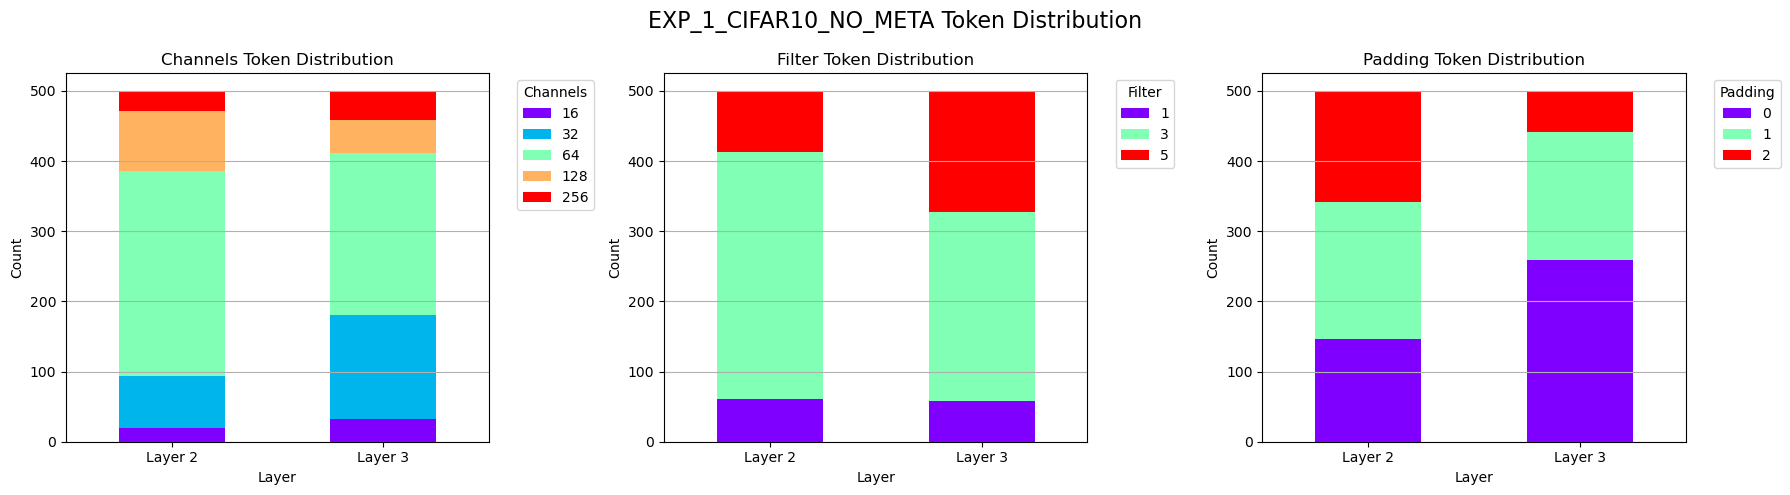

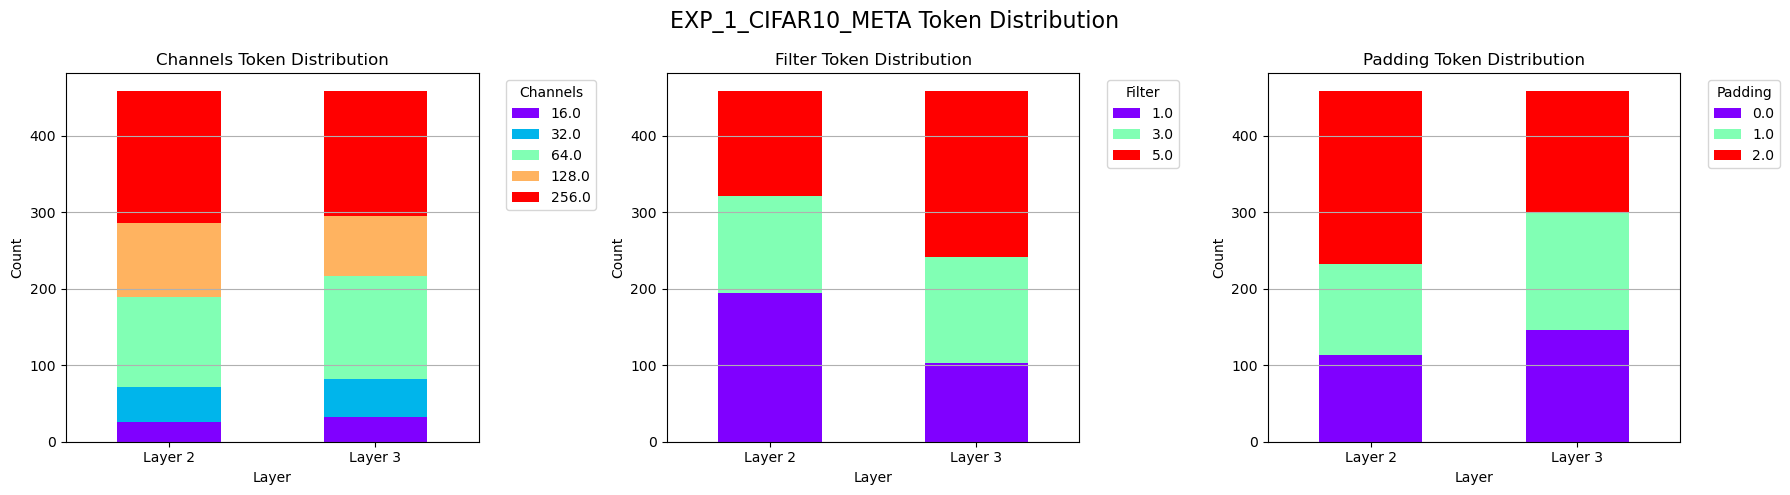

EXP_1_CIFAR10_NO_META Statistics:
             test_acc                   total_param_count                 \
                 mean       std     max              mean            std   
range_label                                                                
0-49         0.754944  0.033403  0.8052         257446.08  333695.990996   
50-99        0.765864  0.029342  0.8052         280324.16  344293.764144   
100-149      0.766268  0.026724  0.8121         243500.80  204145.457226   
150-199      0.759716  0.025922  0.8052         178565.76  163040.337386   
200-249      0.758964  0.026249  0.8151         173442.88  139262.848498   
250-299      0.768060  0.023425  0.8022         158457.92  103742.291536   
300-349      0.764010  0.021012  0.8059         173566.40  135857.053183   
350-399      0.769524  0.022026  0.8070         155675.52  103945.637888   
400-449      0.770244  0.016837  0.8069         151854.40  108671.226182   
450-499      0.776248  0.013962  0.8047         145153

In [30]:
analysis.compare_metrics([df_exp3, df_exp1_meta], df_names=["EXP_6_CIFAR10", "EXP_1_CIFAR10_META"], df_colors=["tab:blue", "tab:orange"], metrics=["train_loss", "test_acc", "max_accuracy", "baseline", "total_param_count"], limit=300)

analysis.plot_token_distribution(df_exp3, "EXP_1_CIFAR10_NO_META", include_layer1=False, use_sns=True, sns_palette="rainbow")
analysis.plot_token_distribution(df_exp1_meta, "EXP_1_CIFAR10_META", include_layer1=False, use_sns=True, sns_palette="rainbow")

print("EXP_1_CIFAR10_NO_META Statistics:")
print(analysis.compute_stats(df_exp3, metrics=["test_acc", "total_param_count"], stats=["mean", "std", "max"]))
print()
print("EXP_1_CIFAR10_META Statistics:")
print(analysis.compute_stats(df_exp1_meta, metrics=["test_acc", "total_param_count"], stats=["mean", "std", "max"]))

Adding model complexity to the reward helped the controller explore smaller architectures while maintaining similar accuracy. Compared to the pure meta controller, the complexity-aware one achieved comparable max accuracy (~82.5% for pure meta vs ~81.5% for complexity-aware) but used significantly fewer parameters on average (e.g., 155k vs. 745k in the final range). It also showed lower variance in parameter counts, indicating more consistent efficiency. While baseline rewards were lower due to the penalty, test accuracy remained stable, confirming that simpler models can perform just as well. Overall, the modified reward led to compact, efficient architectures without significantly hurting performance.

#### Experiment 3 - Can a controller use dataset metadata information to find optimal architectures faster or find better architectures?


In this experiment we want to see the impact of providing dataset-metadata information to our controller.

##### Approach

First we run the controller without using metadata information

In [18]:
experiment_name = "EXP_1_CIFAR10_NO_META"

In [ ]:
run_experiment(
    experiment_name,
    dataset_name="cifar",
    model_iters=300,
    train_epochs=50,
    positions=[1,2],
    reward_function=reward_functions.test_accuracy_reward,
    max_child_layers=2,
    reset_experiment=True,
    use_metadata=False,
)

✅ Fixed padding captured and exported 300 models to LogFiles/Output/EXP_1_CIFAR10_NO_META_log.csv


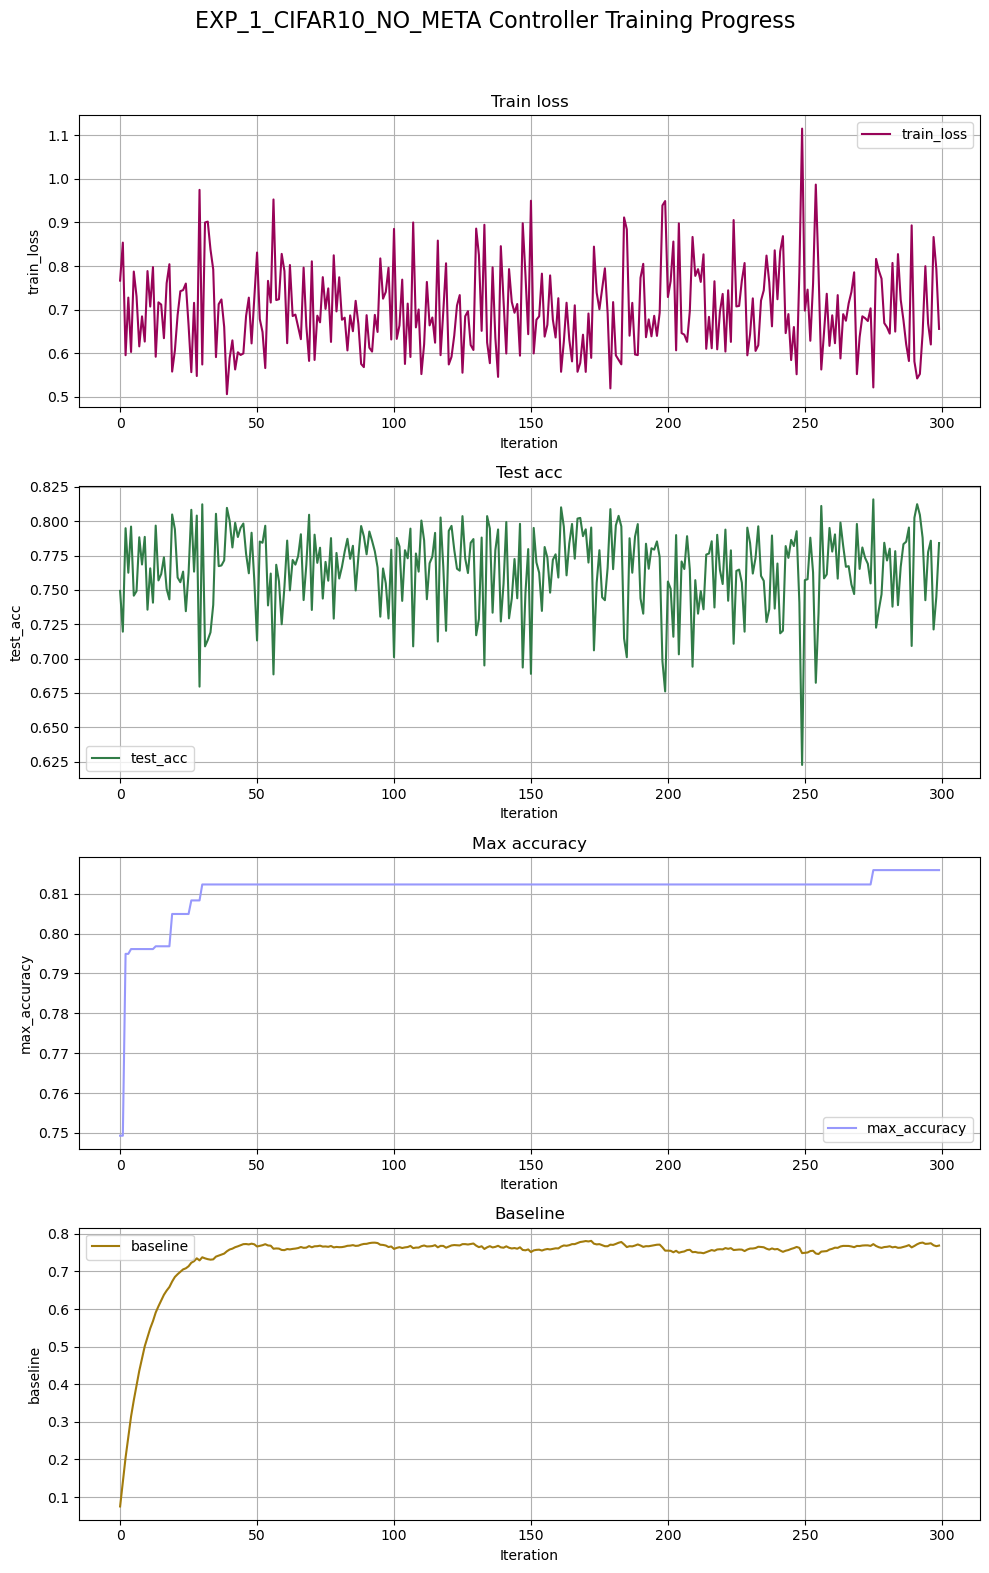

In [19]:
# Plot Training Results
df_exp1_no_meta = analysis.get_full_training_log_data(experiment_name)
analysis.plot_metrics(df_exp1_no_meta, experiment_name, metrics=["train_loss", "test_acc", "max_accuracy", "baseline"], limit=300)

Next we want to run the experiment again but use metadata information

In [20]:
experiment_name = "EXP_1_CIFAR10_META"

In [ ]:
run_experiment(
    experiment_name,
    dataset_name="cifar",
    model_iters=300,
    train_epochs=50,
    positions=[1,2],
    reward_function=reward_functions.test_accuracy_reward,
    max_child_layers=2,
    reset_experiment=True,
    use_metadata=True,
)

✅ Fixed padding captured and exported 459 models to LogFiles/Output/EXP_1_CIFAR10_META_log.csv


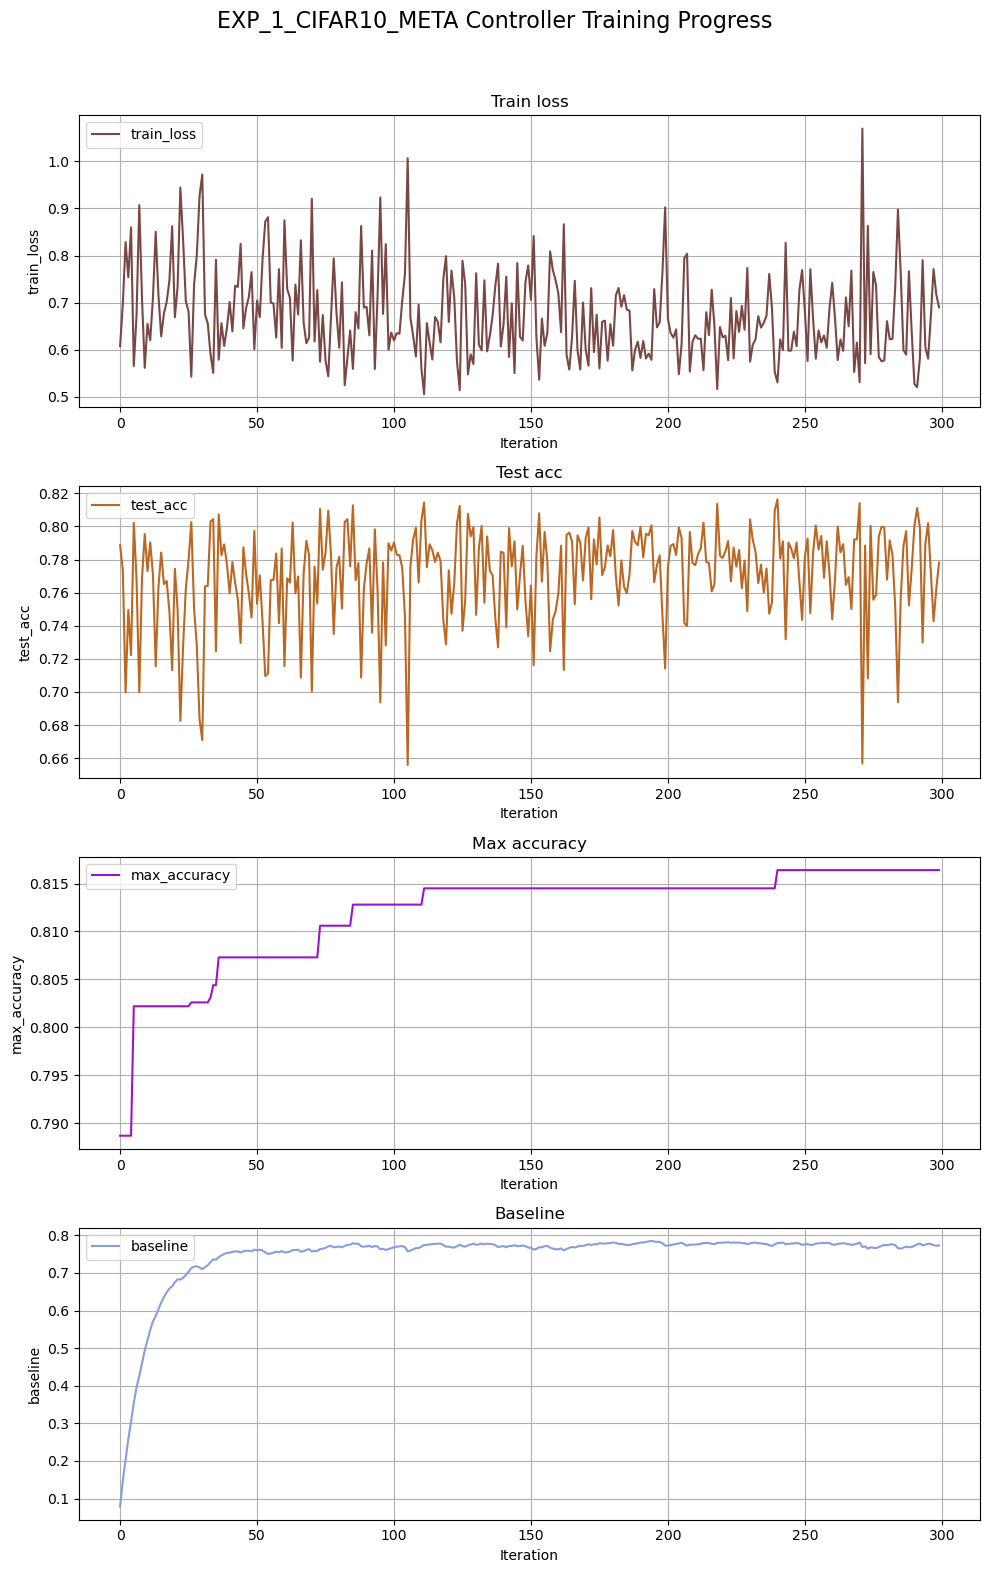

In [21]:
df_exp1_meta = analysis.get_full_training_log_data(experiment_name)
analysis.plot_metrics(df_exp1_meta, experiment_name, metrics=["train_loss", "test_acc", "max_accuracy", "baseline"], limit=300)

##### Analysis

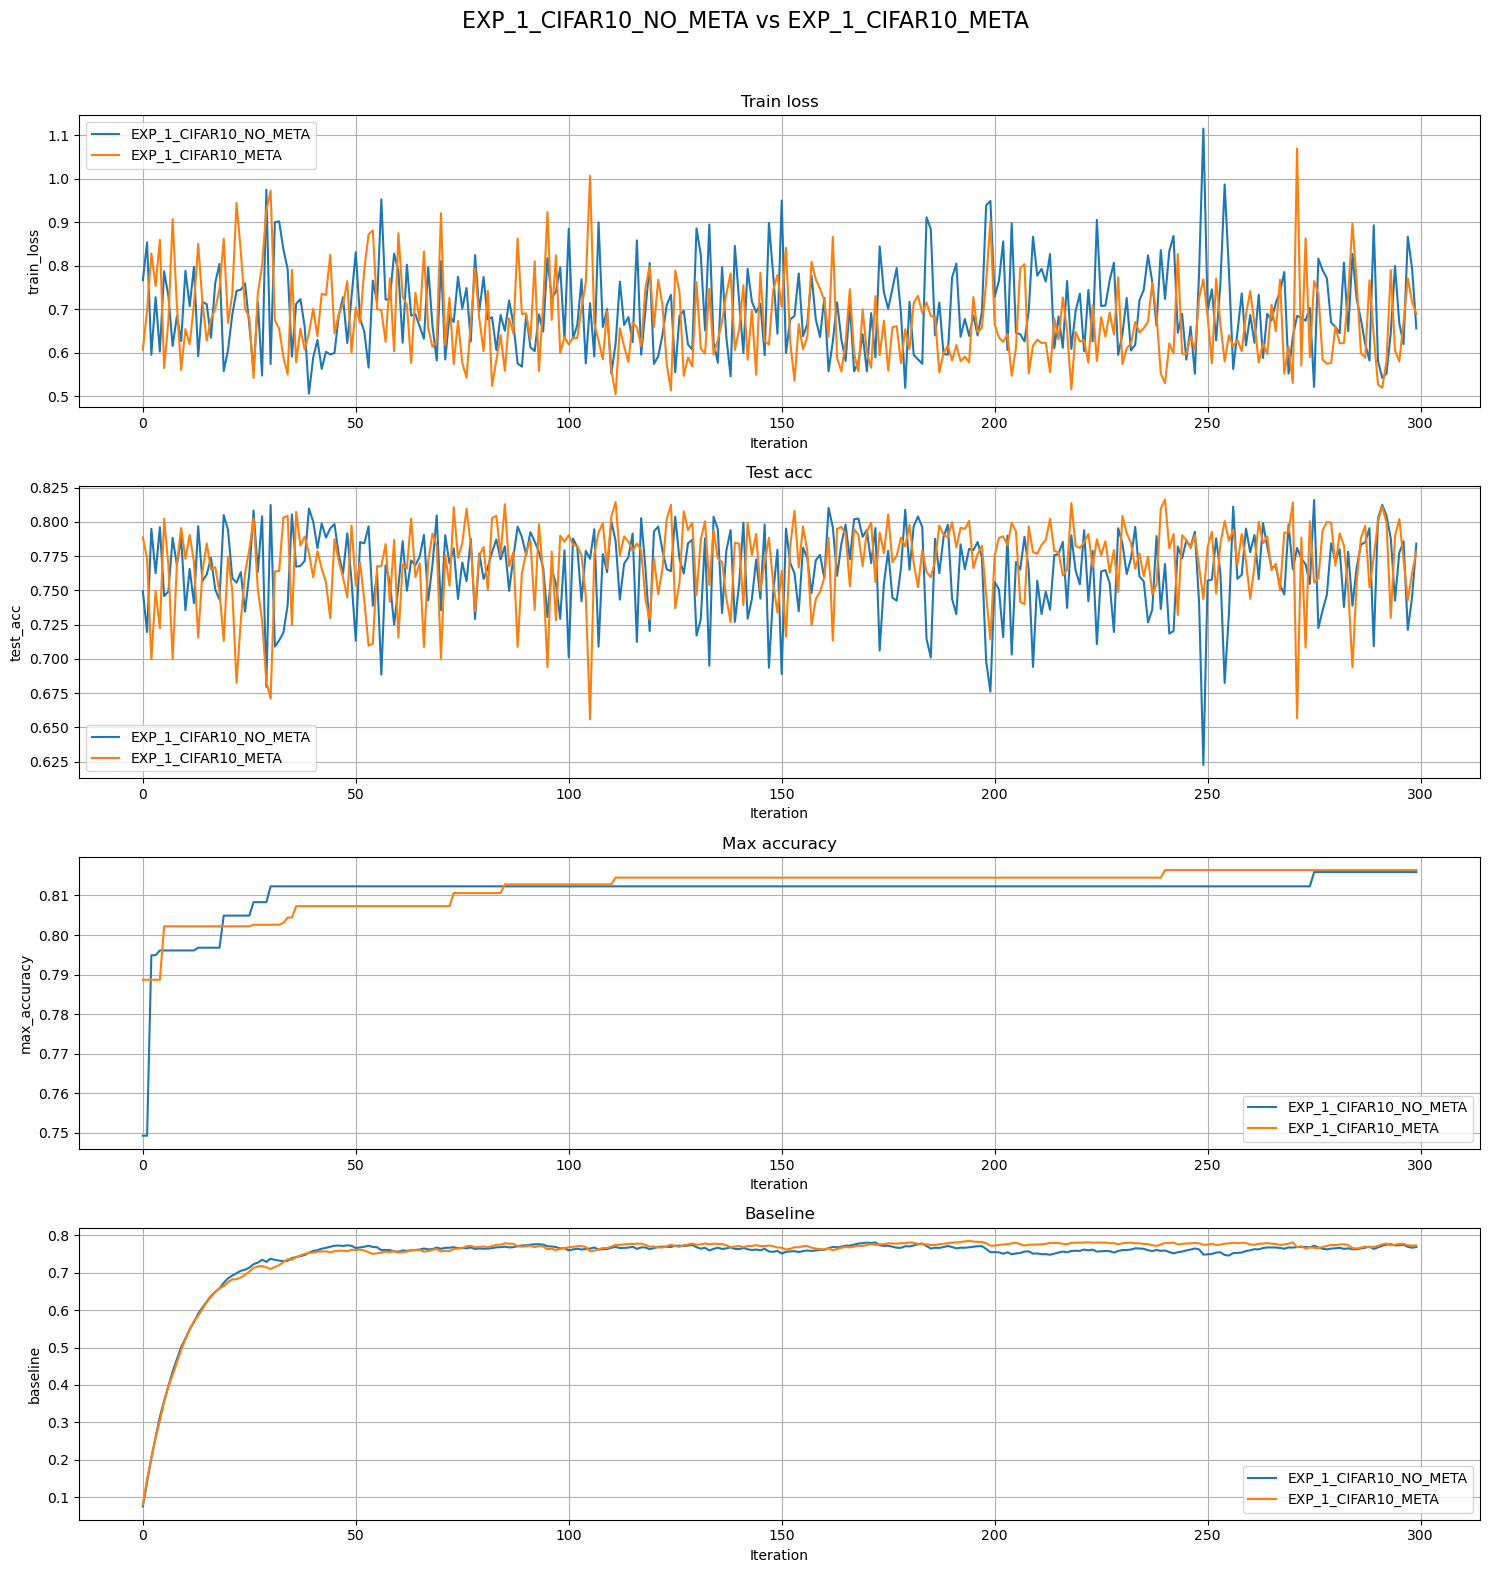

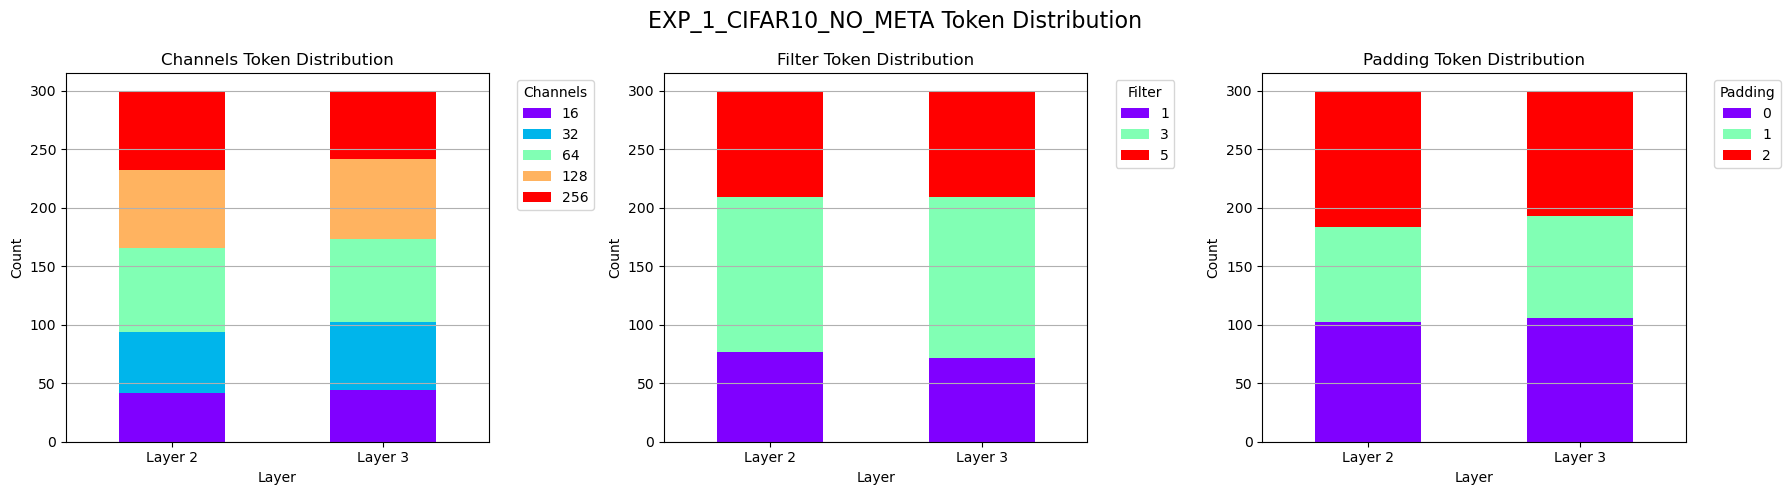

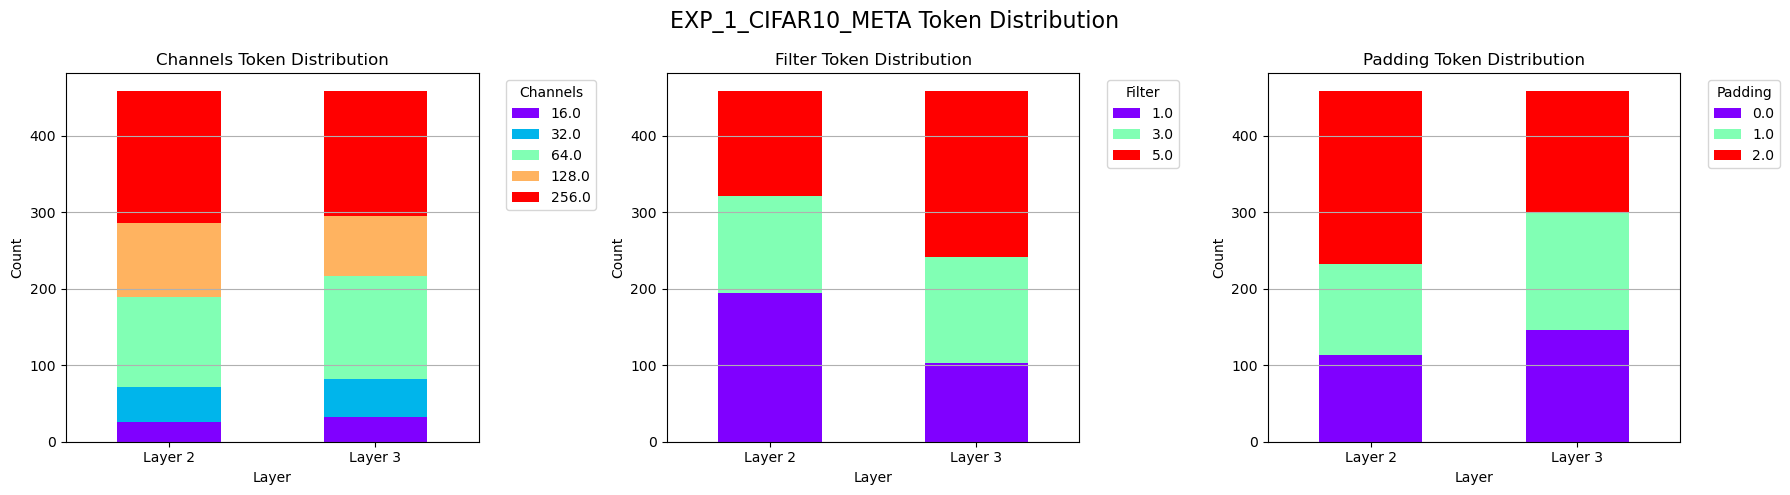

EXP_1_CIFAR10_NO_META Statistics:
             test_acc                    baseline                    
                 mean       std     max      mean       std       max
range_label                                                          
0-49         0.767600  0.029862  0.8123  0.628622  0.179737  0.773777
50-99        0.765590  0.023858  0.8047  0.766626  0.004834  0.776498
100-149      0.764118  0.031471  0.8037  0.765526  0.004078  0.774249
150-199      0.767404  0.032539  0.8101  0.768001  0.007239  0.781275
200-249      0.755822  0.032796  0.7963  0.756999  0.004590  0.765588
250-299      0.768104  0.027678  0.8159  0.764481  0.007289  0.776719

EXP_1_CIFAR10_META Statistics:
             test_acc                    baseline                    
                 mean       std     max      mean       std       max
range_label                                                          
0-49         0.758784  0.033926  0.8073  0.621680  0.176569  0.761689
50-99        0.765034  0

In [24]:
analysis.compare_metrics([df_exp1_no_meta, df_exp1_meta], df_names=["EXP_1_CIFAR10_NO_META", "EXP_1_CIFAR10_META"], df_colors=["tab:blue", "tab:orange"], metrics=["train_loss", "test_acc", "max_accuracy", "baseline"], limit=300)

analysis.plot_token_distribution(df_exp1_no_meta, "EXP_1_CIFAR10_NO_META", include_layer1=False, use_sns=True, sns_palette="rainbow")
analysis.plot_token_distribution(df_exp1_meta, "EXP_1_CIFAR10_META", include_layer1=False, use_sns=True, sns_palette="rainbow")

print("EXP_1_CIFAR10_NO_META Statistics:")
print(analysis.compute_stats(df_exp1_no_meta, metrics=["test_acc", "baseline"], stats=["mean", "std", "max"]))
print()
print("EXP_1_CIFAR10_META Statistics:")
print(analysis.compute_stats(df_exp1_meta, metrics=["test_acc", "baseline"], stats=["mean", "std", "max"]))

The controller trained with metadata shows slightly better and more stable test accuracy over time. It has lower variance in test accuracy, especially after 100 iterations. Its max accuracy reaches 82.5%, slightly higher than the no-meta version’s 81.5%. Both converge quickly, but the metadata model improves steadily after 150 iterations. Token distribution shows the meta controller favors higher channels and more varied filters. Overall, adding metadata leads to smoother training, higher peak accuracy, and a shift in architectural preferences, suggesting it helps the controller learn better designs. The baseline also benefits slightly from metadata, confirming its positive influence on model quality. Meta improves both search stability and output performance.

#### Experiment 4

**Transfer Learning CIFAR10 - 100**

Description <br>
Method <br>
Analysis <br>

### Result Summary

Tabular Format for summarizing all exp